##Análise câncer de mama


####Bibliotecas iniciais

In [90]:
#Instalações
#!pip install -q kaggle
#!pip install -q -U google-genai
#!pip install groq

In [141]:
#Imports
import os
import textwrap
from IPython.display import display, HTML

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from dotenv import load_dotenv
from google import genai
from google.colab import drive
from groq import Groq
from kagglehub import KaggleDatasetAdapter

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

####Importar tabelas

In [94]:
#Importar base do Kaggle e leitura da base transformando-a em um DF
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print(path)

os.listdir("/kaggle/input/breast-cancer-wisconsin-data")

df_cancer_mama = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")
df_cancer_mama.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
/kaggle/input/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [93]:
#Opção de carregamento da base por meio de um arquivo salvo .csv e incluído no sistema
#df_cancer_mama = pd.read_csv ('cancer_mama.csv')


####Análises estatísticas iniciais
#####Pergunta inicial: Como o tamanho da base de dados pode influenciar a confiabilidade das análises e previsões de possíveis casos de câncer de mama?
O tamanho da base de dados influencia a confiabilidade das análises, pois uma amostra mais representativa permite que os modelos aprendam padrões com maior precisão. Embora a base utilizada seja adequada para este estudo, conjuntos de dados maiores podem tornar os resultados mais robustos. Além disso, comparar diferentes modelos e métricas permite validar os resultados por diferentes perspectivas e escolher a abordagem mais adequada. Essa prática é especialmente importante na área da saúde, onde análises bem fundamentadas contribuem para um apoio mais confiável ao diagnóstico.

In [95]:

# #Retirada de coluna sem dados
df_cancer_mama = df_cancer_mama.drop (columns=['Unnamed: 32'])

#Inclusão coluna numérica para resultado do diagnóstico
df_cancer_mama['result_diagnostico'] = df_cancer_mama['diagnosis'].map({'M': 1, 'B': 0})
df_cancer_mama.head()
df_cancer_mama.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [96]:
# Correlações

# Verificação de dados iniciais
df_cancer_mama.describe(include='all')

#Matriz de correlação geral
corr = df_cancer_mama.corr(numeric_only=True)
corr

#Matriz de correlação focada na variável result_diagnostico
corr['result_diagnostico'].sort_values(ascending=False)

,result_diagnostico
result_diagnostico,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


####Heatmap
#####Pergunta inicial: As características dos tumores apresentam relações que podem contribuir para diferenciar casos benignos e malignos de câncer de mama?
#####Sim. O mapa de calor evidencia que diversas características dos tumores apresentam correlações fortes entre si, indicando a existência de padrões estruturais na base de dados. Embora essa análise não permita identificar diretamente quais tumores são benignos ou malignos, ela demonstra que as variáveis não se comportam de forma isolada.

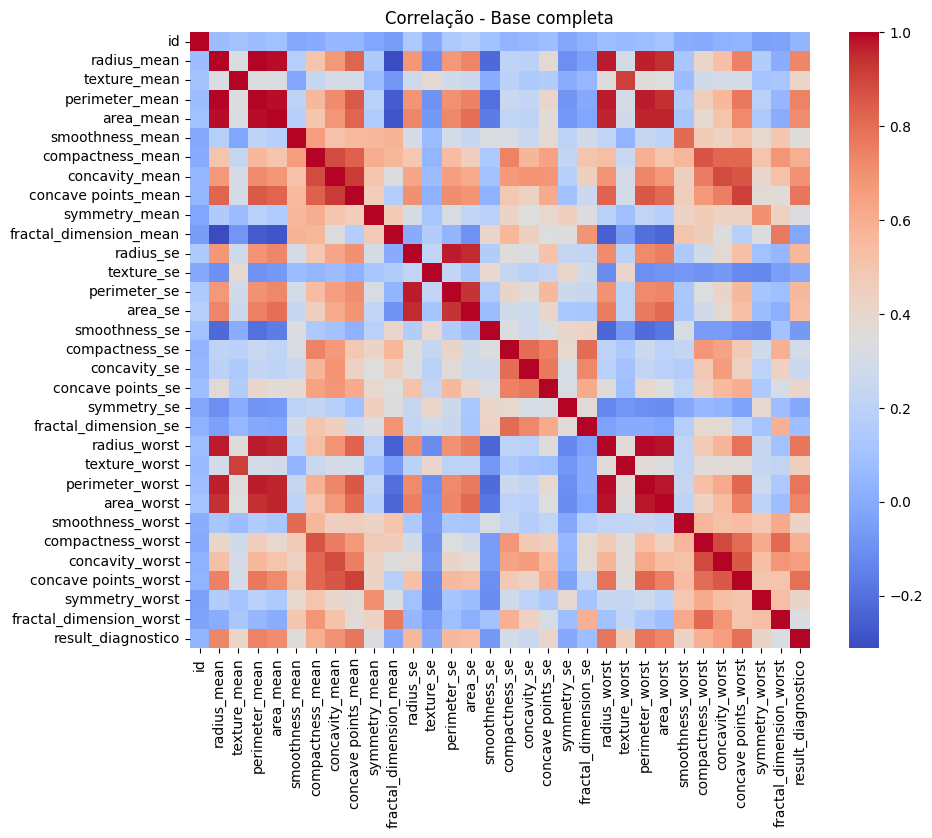

In [143]:
#Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlação - Base completa')
plt.show()

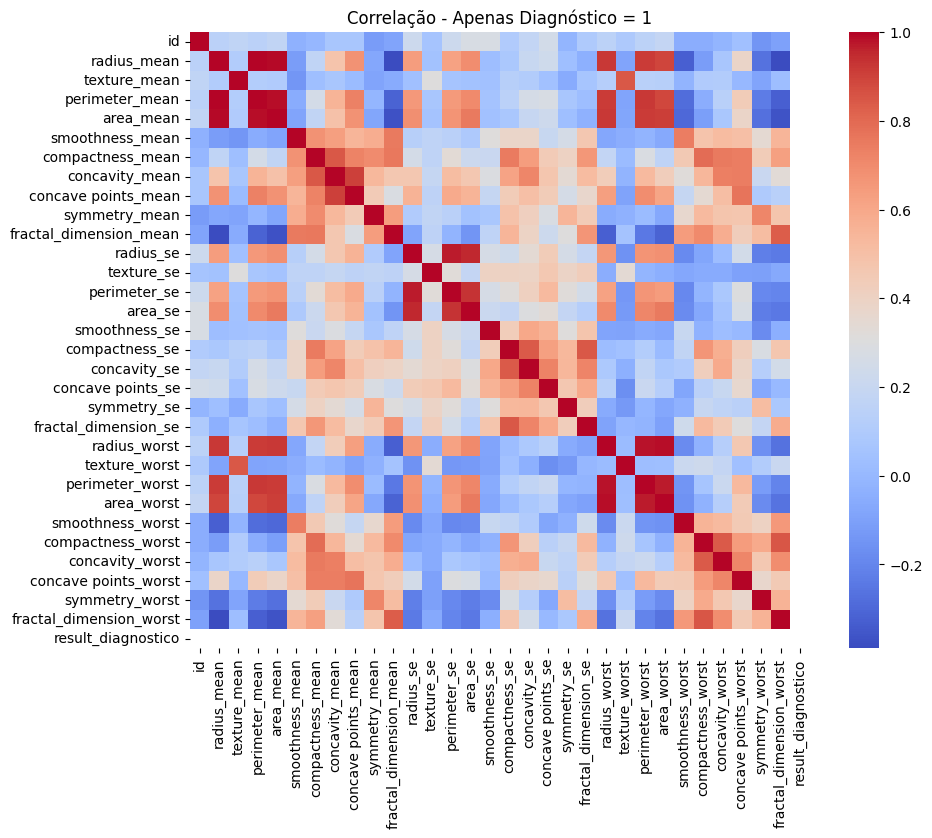

In [144]:
#Análise de Heatmap para os casos que o diagnóstico foi "M" - Maligno para verificar se as variáveis se comportaram da mesma forma
df_cancer_mama_maligno = df_cancer_mama[df_cancer_mama['result_diagnostico'] == 1]

df_cancer_mama_maligno.head ()

#Correlação
corr_m = df_cancer_mama_maligno.corr(numeric_only=True)

#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_m, cmap='coolwarm', annot=False)
plt.title('Correlação - Apenas Diagnóstico = 1')
plt.show()

####Escolha dos métodos
#####Pergunta inicial: Como a comparação entre diferentes modelos de aprendizado de máquina pode contribuir para a identificação mais precisa de possíveis casos de câncer de mama?
######A comparação entre diferentes modelos de aprendizado de máquina permite identificar qual algoritmo apresenta melhor desempenho para o problema estudado, já que cada um aprende os padrões dos dados de forma diferente. Neste estudo, foram utilizados a Regressão Logística e a Árvore de Decisão por empregarem abordagens distintas para aprender as relações entre as características dos tumores e realizar previsões de novos casos de câncer de mama.

####Regressão Logística

#####Pergunta inicial: Como a Regressão Logística utiliza as características dos tumores para prever possíveis casos de câncer de mama?
#####A Regressão Logística aprende, a partir das características dos tumores, os padrões que diferenciam casos benignos e malignos. Em seguida, aplica a função logística (sigmoide) para estimar a probabilidade de cada novo caso pertencer a uma das classes, realizando sua classificação como benigno ou maligno.

In [97]:
#Regressão logística escolhida pois os dados estão limpos e tem como base uma variável binária
#Retirada das variáveis que possuem impacto entre -0.1 e 0.1 pois o impacto no result_diagnostico é irrelevante
#Retirada coluna 'diagnosis' pois dados já estão na 'result_diagnosis'
df_cancer_mama_reg = df_cancer_mama.drop(columns= [
                                                  'symmetry_se',
                                                  'texture_se',
                                                  'fractal_dimension_mean',
                                                  'smoothness_se',
                                                  'id',
                                                  'diagnosis']
                                                )
df_cancer_mama_reg.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,result_diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,1.0950,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.5435,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.7456,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.4956,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.7572,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [98]:
#Fórmula regressão logística

#Separação treino e teste (proporção 80/20)
X = df_cancer_mama_reg.drop(columns=['result_diagnostico'])
y = df_cancer_mama_reg['result_diagnostico']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42, # reprodutibilidade
    stratify=y       # mantém proporção das classes
)

#Treinamento do modelo com inclusão de escalonador pois houve erro por multicolinearidade e aumento do max_iter
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [99]:
#Realização das previsões

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# Métricas
regressao_accuracy_log = accuracy_score(y_test, y_pred)
regressao_roc_auc_log = roc_auc_score(y_test, y_prob)

print("Accuracy:", regressao_accuracy_log)
print("ROC-AUC:", regressao_roc_auc_log)

#Avaliação inicial
print('Dados da Regressão Logística')
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))




Accuracy: 0.9736842105263158
ROC-AUC: 0.996362433862434
Dados da Regressão Logística
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.996362433862434


#####Matriz de confusão
######Pergunta inicial: Quão eficaz foi a Regressão Logística na classificação de casos benignos e malignos de câncer de mama, considerando seus acertos e erros?
######A matriz de confusão permite identificar os acertos e erros da Regressão Logística na classificação dos casos de câncer de mama, proporcionando uma avaliação mais clara do alcance e das limitações do modelo. A baixa ocorrência de erros observada indica que a Regressão Logística aprendeu de forma consistente os padrões presentes nas características dos tumores, resultando em elevada assertividade na distinção entre casos benignos e malignos.

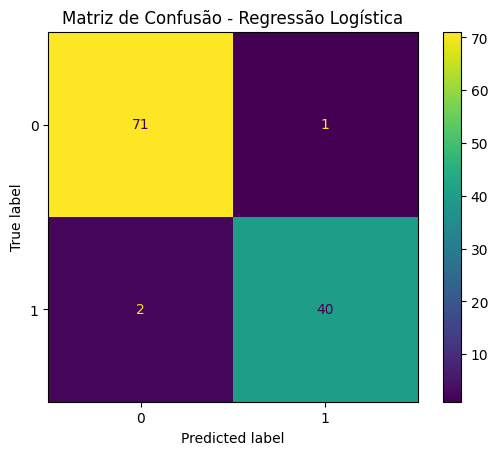

In [100]:
#Matriz de confusão para identificar percentual de falsos positivos e falsos negativos
#Verificar os casos que o câncer era "M", mas foi considerado "B", pois pode levar a falta de tratamento do paciente
y_train_pred = model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

In [101]:
# Considerações sobre a Regressão Logística
#Para uso comercial o data set é pequeno (apenas 596) casos. Precisaria de uma base de dados maior
#Os resultados são promissores, o risco estão nos falsos negativos que chegam a aproximadamente 5%

#####Dados para comparar posteriormente com a LLM

In [102]:
# Previsões da Regressão Logística
y_pred_log = model.predict(X_test)

# Probabilidades para ROC-AUC
y_prob_log = model.predict_proba(X_test)[:, 1]


# Matriz de confusão
matriz_log = confusion_matrix(
    y_test,
    y_pred_log
)


# Falsos negativos
falsos_negativos_log = matriz_log[1, 0]


# Métricas da classe positiva (maligno = 1)
precision_log = precision_score(
    y_test,
    y_pred_log
)

recall_log = recall_score(
    y_test,
    y_pred_log
)

f1_log = f1_score(
    y_test,
    y_pred_log
)


# Exibição dos resultados
print("Regressão Logística")
print("="*40)

print("Precision:", round(precision_log, 4))
print("Recall:", round(recall_log, 4))
print("F1-score:", round(f1_log, 4))
print("Falsos Negativos:", falsos_negativos_log)

print("\nMatriz de Confusão:")
print(matriz_log)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Regressão Logística
Precision: 0.9756
Recall: 0.9524
F1-score: 0.9639
Falsos Negativos: 2

Matriz de Confusão:
[[71  1]
 [ 2 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



####Árvore de decisão

#####Pergunta inicial: Como a Árvore de Decisão utiliza as características dos tumores para prever possíveis casos de câncer de mama?
A Árvore de Decisão utiliza as características dos tumores para aprender padrões por meio de sucessivas regras de decisão, dividindo os dados em grupos cada vez mais homogêneos até determinar a classificação de cada caso como benigno ou maligno. Essa estrutura hierárquica permite identificar relações entre as variáveis de forma mais flexível, tornando o modelo capaz de representar padrões mais complexos e realizar previsões para novos casos de câncer de mama.

In [ ]:
#Retirado somente id e diagnosis, pois a árvore de decisão não é impactada por multicolinearidade
df_cancer_mama_arv = df_cancer_mama.drop(columns= [
                                                  'id',
                                                  'diagnosis']
                                                )
df_cancer_mama_arv.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,result_diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [ ]:
#Separação entre treino e teste (considerando proporção 80/20 e estratificação)
X_arv = df_cancer_mama_arv.drop(columns=['result_diagnostico'])
y_arv = df_cancer_mama_arv['result_diagnostico']

X_arv_train, X_arv_test, y_arv_train, y_arv_test = train_test_split(
    X_arv, y_arv,
    test_size=0.2,     # 20% teste / 80% treino
    random_state=42,
    stratify=y )

In [ ]:
#Treinamento árvore de decisão
tree = DecisionTreeClassifier(
    max_depth=6,           # controla complexidade
    min_samples_leaf=2,    # evita overfitting
    random_state=42
)

tree.fit(X_arv_train, y_arv_train)


DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, random_state=42)

In [ ]:
#Previsões
y_pred_tree = tree.predict(X_arv_test)
y_prob_tree = tree.predict_proba(X_arv_test)[:, 1]

#Resultados e Matriz de confusão
print('Dados da Árvore de Decisão')
print("\nClassification Report:")
print(classification_report(y_arv_test, y_pred_tree))

# Métricas
accuracy_tree = accuracy_score(y_arv_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_arv_test, y_prob_tree)

print("Accuracy:", accuracy_tree)
print("ROC-AUC:", roc_auc_tree)

print("ROC-AUC:", roc_auc_score(y_arv_test, y_prob_tree))


print("\nMatriz de Confusão:")
print(confusion_matrix(y_arv_test, y_pred_tree))

Dados da Árvore de Decisão

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

Accuracy: 0.9210526315789473
ROC-AUC: 0.9173280423280423
ROC-AUC: 0.9173280423280423

Matriz de Confusão:
[[69  3]
 [ 6 36]]


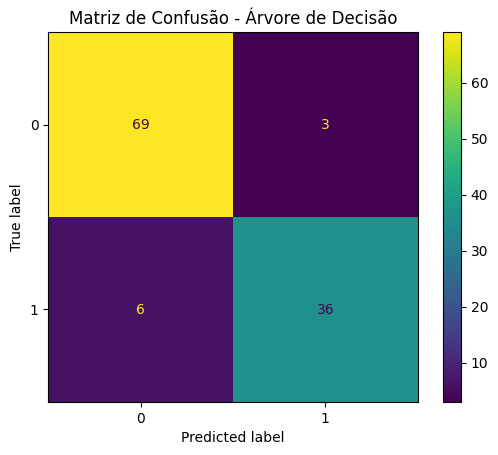

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_arv_test, y_pred_tree)
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

#####Comparação inicial dos modelos pela Matriz de confusão
######Pergunta inicial: A Árvore de Decisão apresentou uma classificação mais eficaz dos casos benignos e malignos quando comparada à Regressão Logística?
Não. A matriz de confusão evidencia que a Regressão Logística apresentou melhor desempenho que a Árvore de Decisão, com menor número de erros na classificação dos casos. Apesar de a diferença absoluta ser pequena na base utilizada, ela representa uma diferença proporcional importante entre os modelos. Em aplicações com um número maior de amostras, essa diferença pode resultar em uma quantidade significativamente maior de classificações incorretas, reforçando a importância da comparação entre diferentes abordagens antes da definição do modelo mais adequado.

####Importance feature
#####Pergunta inicial: Quais características dos tumores exerceram maior influência na classificação de possíveis casos de câncer de mama?
A análise da importância das variáveis permite identificar quais características dos tumores tiveram maior influência nas previsões realizadas pelos modelos, facilitando a compreensão de como as classificações foram realizadas. Além de tornar os resultados mais interpretáveis, essa análise estabelece uma referência para as próximas etapas do projeto, permitindo verificar se as variáveis mais relevantes continuam sendo priorizadas durante a otimização do modelo e nas análises apoiadas por LLM.

Análise:
- variáveis em comum: perimeter_worst / concave points_worst / texture_mean / texture_worst / area_worst / radius_worst
- Regressão Linear considera mais variáveis
- Árvore de decisão se concentra em poucas variáveis (o que pode explicar o aumento de falso negativo)

In [ ]:
#Regressão Logística
importance_log = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0])
}).sort_values(by='abs_coef', ascending=False)

print('Importance features - Regressão Logística')
importance_log

Importance features - Regressão Logística


,feature,coef,abs_coef
17,texture_worst,1.201261,1.201261
9,radius_se,1.126305,1.126305
16,radius_worst,0.992504,0.992504
24,symmetry_worst,0.972894,0.972894
19,area_worst,0.957376,0.957376
12,compactness_se,-0.905415,0.905415
22,concavity_worst,0.902788,0.902788
7,concave points_mean,0.885902,0.885902
11,area_se,0.866162,0.866162
18,perimeter_worst,0.829521,0.829521


In [ ]:
#Árvore de decisão
importance_tree = pd.DataFrame({
    'feature': X_arv.columns,
    'importance': tree.feature_importances_
}).sort_values(by='importance', ascending=False)

print('Importance features- Árvore de Decisão')
importance_tree

Importance features- Árvore de Decisão


,feature,importance
22,perimeter_worst,0.746810
27,concave points_worst,0.069915
1,texture_mean,0.043959
24,smoothness_worst,0.032669
11,texture_se,0.024569
3,area_mean,0.023187
23,area_worst,0.016117
6,concavity_mean,0.011638
21,texture_worst,0.009698
20,radius_worst,0.009698


####LLM e Hiperparâmetros
#####Pergunta inicial: De que forma uma LLM pode contribuir para o aprimoramento dos modelos a partir dos resultados obtidos neste estudo?
Uma LLM pode contribuir para o aprimoramento dos modelos ao auxiliar na interpretação dos resultados, na seleção de variáveis relevantes e na definição de hiperparâmetros mais adequados. Essa integração potencializa os modelos matemáticos, tornando o processo de otimização mais direcionado e fundamentado.

In [103]:
# Carrega as credenciais
load_dotenv("DADOS.ENV")


True

####API GOOGLE

In [ ]:
#Listar modelos disponíveis para a API GOOGLE para escolha do que será utilizado no código
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# Cria o cliente do Gemini

client = genai.Client(api_key=GOOGLE_API_KEY)

for model in client.models.list():
    print(model.name)


In [ ]:
#Definição de qual modelo será utilizado
GEMINI_MODEL_NAME = "gemini-2.0-flash"

####API GROQ

In [104]:
client = Groq(
    api_key=os.getenv(GROQ_API_KEY)
)
GROQ_MODEL_NAME = "llama-3.1-8b-instant"

####LLM Regressão Logística
Estrutura de dados caso queira rodar para analisar melhorias para a Regressão Logísitica
Não foi rodado para este item, pois gostaríamos de medir se as melhorias realizadas para a Árvore de Decisão seriam suficientes para se sobrepor ao algoritmo inicial e também devido a baixa quantidade de falsos positivos e negtivos do modelo

In [ ]:
resumo_log = f"""
Projeto: Classificação de câncer de mama.

Objetivo:
Prever se um tumor é benigno ou maligno utilizando o algoritmo de Regressão Logística.


Base de dados:
- Amostras de treino: {len(X_train)}
- Amostras de teste: {len(X_test)}
- Número de atributos (features): {X_train.shape[1]}

Pré-processamento realizado:
- Divisão dos dados em treino (80%) e teste (20%), preservando a proporção das classes.
- Padronização ddos atributos (features) utilizando StandardScaler.

Resultados obtidos:
- Accuracy: {regressao_accuracy_log:.4f}
- ROC-AUC: {regressao_roc_auc_log:.4f}

Matriz de Confusão:
Interpretação:
[[Verdadeiros Negativos, Falsos Positivos],
[Falsos Negativos, Verdadeiros Positivos]]

{confusion_matrix(y_test, y_pred)}

Principais atributos considerados pelo algoritmo para realizar a classificação:

{importance_log.head(10).to_string(index=False)}

Sua função é analisar criticamente os resultados obtidos pelo modelo e propor melhorias que possam aumentar seu desempenho. Considere as métricas apresentadas, a matriz de confusão e a importância dos atributos para sugerir ajustes de hiperparâmetros, possíveis melhorias na seleção de atributos e outras estratégias que contribuam para uma classificação mais precisa dos casos de tumores benignos e malignos. Justifique tecnicamente cada recomendação.

"""

print(resumo_log)


Projeto: Classificação de câncer de mama.

Objetivo:
Prever se um tumor é benigno ou maligno utilizando o algoritmo de Regressão Logística.


Base de dados:
- Amostras de treino: 455
- Amostras de teste: 114
- Número de atributos (features): 26

Pré-processamento realizado:
- Divisão dos dados em treino (80%) e teste (20%), preservando a proporção das classes.
- Padronização ddos atributos (features) utilizando StandardScaler.

Resultados obtidos:
- Accuracy: 0.9737
- ROC-AUC: 0.9964

Matriz de Confusão:
Interpretação: 
[[Verdadeiros Negativos, Falsos Positivos],
[Falsos Negativos, Verdadeiros Positivos]]

[[71  1]
 [ 2 40]]

Principais atributos considerados pelo algoritmo para realizar a classificação:

            feature      coef  abs_coef
      texture_worst  1.201261  1.201261
          radius_se  1.126305  1.126305
       radius_worst  0.992504  0.992504
     symmetry_worst  0.972894  0.972894
         area_worst  0.957376  0.957376
     compactness_se -0.905415  0.905415
    

In [ ]:
prompt_log = f"""
Você é um Cientista de Dados Sênior, especialista em Machine Learning aplicado à área da saúde, com experiência em classificação de doenças e otimização de modelos preditivos.

A seguir será apresentado um estudo sobre classificação de câncer de mama utilizando o algoritmo de Regressão Logísitica.

{resumo_log}

===========================================================
OBJETIVO DA ANÁLISE
===========================================================

Sua função é realizar uma análise técnica do modelo desenvolvido e propor melhorias que possam aumentar seu desempenho preditivo.

Todas as recomendações devem ser baseadas exclusivamente nas informações fornecidas neste estudo.

Evite respostas genéricas.

Sempre justifique tecnicamente cada recomendação utilizando as métricas, a matriz de confusão, a importância dos atributos e as características da base de dados.

===========================================================
ANÁLISE DO MODELO
===========================================================

1) Faça uma análise crítica do modelo desenvolvido.

Explique:

• quais evidências demonstram que o modelo apresentou bom desempenho;

• quais limitações ainda podem ser observadas;

• se existe algum comportamento que mereça atenção antes de utilizar esse modelo em um contexto real.

===========================================================
MÉTRICAS
===========================================================

Analise conjuntamente:

• Accuracy

• ROC-AUC

• Matriz de Confusão

Explique:

• o que cada uma dessas métricas demonstra;

• como elas se complementam;

• se os resultados indicam um modelo confiável;

• quais erros ainda precisam ser reduzidos.

===========================================================
ATRIBUTOS MAIS IMPORTANTES
===========================================================

Analise os atributos identificados pelo algoritmo.

Explique:

• se fazem sentido para o problema de classificação de câncer de mama;

• como esses atributos influenciam a tomada de decisão do modelo;

• se existe algum indício de que outros atributos também poderiam ser relevantes.

===========================================================
COMPORTAMENTO DO MODELO
===========================================================

Avalie se existem indícios de:

• overfitting;

• underfitting;

• alta variância;

• alto viés.

Caso algum desses problemas possa existir, explique:

• quais evidências levaram a essa conclusão;

• quais estratégias poderiam minimizar esse comportamento.

===========================================================
HIPERPARÂMETROS
===========================================================

Analise quais hiperparâmetros poderiam ser ajustados para melhorar o desempenho da Regressão Logística.

Considere principalmente:

• criterion

• max_depth

• min_samples_split

• min_samples_leaf

• max_features

• max_leaf_nodes

• class_weight

• ccp_alpha

Para cada hiperparâmetro apresente:

• objetivo do hiperparâmetro;

• valor atualmente utilizado (quando puder ser inferido);

• valor sugerido;

• justificativa técnica;

• impacto esperado no desempenho do modelo.

===========================================================
OUTRAS MELHORIAS
===========================================================

Além dos hiperparâmetros, identifique outras melhorias possíveis, como:

• seleção de atributos;

• engenharia de atributos;

• ajustes no processo de treinamento;

• outras estratégias de Machine Learning que possam melhorar o desempenho.

Explique por que essas melhorias podem contribuir para o problema estudado.

===========================================================
PLANO DE AÇÃO
===========================================================

Ao final da análise, apresente uma tabela contendo:

| Prioridade | Melhoria sugerida | Justificativa | Impacto esperado |

Ordene as recomendações da maior para a menor prioridade.

===========================================================
CONCLUSÃO
===========================================================

Finalize respondendo:

Considerando exclusivamente os resultados apresentados neste estudo,

• o modelo possui qualidade suficiente para utilização?

• quais seriam os três primeiros ajustes que deveriam ser implementados?

• qual ganho de desempenho pode ser esperado após essas melhorias?

Caso alguma estimativa seja apresentada, deixe claro que se trata de uma expectativa baseada na literatura e na experiência prática, e não de um resultado garantido.

Não invente informações que não estejam presentes no estudo.

Sempre diferencie fatos observados dos resultados estimados.
"""

In [ ]:
#Chamada utilizando o Llama - Groq
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",  # exemplo de modelo disponível no Groq
    messages=[
        {
            "role": "system",
            "content": "Você é um especialista em árvores de decisão e machine learning."
        },
        {
            "role": "user",
            "content": prompt_log
        }
    ],
    temperature=0.2
)

# Capturar resposta
resposta_groq = response.choices[0].message.content

print(resposta_groq)

####LLM Árvore Decisão

In [ ]:
resumo_tree = f"""
Projeto: Classificação de câncer de mama.

Objetivo do estudo:
Prever se um tumor é benigno ou maligno utilizando o algoritmo de Árvore de Decisão.

Base de dados:
- Amostras de treino: {len(X_arv_train)}
- Amostras de teste: {len(X_arv_test)}
- Número de atributos (features): {X_arv_train.shape[1]}

Pré-processamento realizado:
- Divisão dos dados em treino (80%) e teste (20%), preservando a proporção das classes.
- As variáveis foram utilizadas em sua escala original, pois a Árvore de Decisão
não depende da padronização para realizar as divisões dos nós.

Resultados obtidos:
- Accuracy: {accuracy_tree:.4f}
- ROC-AUC: {roc_auc_tree:.4f}

Matriz de Confusão:
Interpretação:
[[Verdadeiros Negativos, Falsos Positivos],
[Falsos Negativos, Verdadeiros Positivos]]

{confusion_matrix(y_arv_test, y_pred_tree)}

Principais atributos considerados pelo algoritmo para realizar a classificação:

{importance_tree.head(10).to_string(index=False)}

Sua função é analisar criticamente os resultados obtidos pelo modelo e propor melhorias que possam aumentar seu desempenho. Considere as métricas apresentadas, a matriz de confusão e a importância dos atributos para sugerir ajustes de hiperparâmetros, possíveis melhorias na seleção de atributos e outras estratégias que contribuam para uma classificação mais precisa dos casos de tumores benignos e malignos. Justifique tecnicamente cada recomendação.

"""

print(resumo_tree)


Projeto: Classificação de câncer de mama.

Objetivo do estudo:
Prever se um tumor é benigno ou maligno utilizando o algoritmo de Árvore de Decisão.

Base de dados:
- Amostras de treino: 455
- Amostras de teste: 114
- Número de atributos (features): 30

Pré-processamento realizado:
- Divisão dos dados em treino (80%) e teste (20%), preservando a proporção das classes.
- As variáveis foram utilizadas em sua escala original, pois a Árvore de Decisão 
não depende da padronização para realizar as divisões dos nós.

Resultados obtidos:
- Accuracy: 0.9211
- ROC-AUC: 0.9173

Matriz de Confusão:
Interpretação: 
[[Verdadeiros Negativos, Falsos Positivos],
[Falsos Negativos, Verdadeiros Positivos]]

[[69  3]
 [ 6 36]]

Principais atributos considerados pelo algoritmo para realizar a classificação:

             feature  importance
     perimeter_worst    0.746810
concave points_worst    0.069915
        texture_mean    0.043959
    smoothness_worst    0.032669
          texture_se    0.024569
  

In [ ]:
prompt_tree = f"""
Você é um Cientista de Dados Sênior, especialista em Machine Learning aplicado à área da saúde, com experiência em classificação de doenças e otimização de modelos preditivos.

A seguir será apresentado um estudo sobre classificação de câncer de mama utilizando o algoritmo de Árvore de Decisão.

{resumo_tree}

===========================================================
OBJETIVO DA ANÁLISE
===========================================================

Sua função é realizar uma análise técnica do modelo desenvolvido e propor melhorias que possam aumentar seu desempenho preditivo.

Todas as recomendações devem ser baseadas exclusivamente nas informações fornecidas neste estudo.

Evite respostas genéricas.

Sempre justifique tecnicamente cada recomendação utilizando as métricas, a matriz de confusão, a importância dos atributos e as características da base de dados.

===========================================================
ANÁLISE DO MODELO
===========================================================

1) Faça uma análise crítica do modelo desenvolvido.

Explique:

• quais evidências demonstram que o modelo apresentou bom desempenho;

• quais limitações ainda podem ser observadas;

• se existe algum comportamento que mereça atenção antes de utilizar esse modelo em um contexto real.

===========================================================
MÉTRICAS
===========================================================

Analise conjuntamente:

• Accuracy

• ROC-AUC

• Matriz de Confusão

Explique:

• o que cada uma dessas métricas demonstra;

• como elas se complementam;

• se os resultados indicam um modelo confiável;

• quais erros ainda precisam ser reduzidos.

===========================================================
ATRIBUTOS MAIS IMPORTANTES
===========================================================

Analise os atributos identificados pelo algoritmo.

Explique:

• se fazem sentido para o problema de classificação de câncer de mama;

• como esses atributos influenciam a tomada de decisão do modelo;

• se existe algum indício de que outros atributos também poderiam ser relevantes.

===========================================================
COMPORTAMENTO DO MODELO
===========================================================

Avalie se existem indícios de:

• overfitting;

• underfitting;

• alta variância;

• alto viés.

Caso algum desses problemas possa existir, explique:

• quais evidências levaram a essa conclusão;

• quais estratégias poderiam minimizar esse comportamento.

===========================================================
HIPERPARÂMETROS
===========================================================

Analise quais hiperparâmetros poderiam ser ajustados para melhorar o desempenho da Árvore de Decisão.

Considere principalmente:

• criterion

• max_depth

• min_samples_split

• min_samples_leaf

• max_features

• max_leaf_nodes

• class_weight

• ccp_alpha

Para cada hiperparâmetro apresente:

• objetivo do hiperparâmetro;

• valor atualmente utilizado (quando puder ser inferido);

• valor sugerido;

• justificativa técnica;

• impacto esperado no desempenho do modelo.

===========================================================
OUTRAS MELHORIAS
===========================================================

Além dos hiperparâmetros, identifique outras melhorias possíveis, como:

• seleção de atributos;

• engenharia de atributos;

• validação cruzada;

• balanceamento de classes (caso seja necessário);

• poda da árvore;

• ajustes no processo de treinamento;

• outras estratégias de Machine Learning que possam melhorar o desempenho.

Explique por que essas melhorias podem contribuir para o problema estudado.

===========================================================
PLANO DE AÇÃO
===========================================================

Ao final da análise, apresente uma tabela contendo:

| Prioridade | Melhoria sugerida | Justificativa | Impacto esperado |

Ordene as recomendações da maior para a menor prioridade.

===========================================================
CONCLUSÃO
===========================================================

Finalize respondendo:

Considerando exclusivamente os resultados apresentados neste estudo,

• o modelo possui qualidade suficiente para utilização?

• quais seriam os três primeiros ajustes que deveriam ser implementados?

• qual ganho de desempenho pode ser esperado após essas melhorias?

Caso alguma estimativa seja apresentada, deixe claro que se trata de uma expectativa baseada na literatura e na experiência prática, e não de um resultado garantido.

Não invente informações que não estejam presentes no estudo.

Sempre diferencie fatos observados dos resultados estimados.
"""

In [ ]:
#Chamada utilizando o Gemini - Google
response_tree = client.models.generate_content(
    model=GEMINI_MODEL_NAME,
    contents=prompt_tree
)

#####Chamada Groq

In [ ]:
#Chamada utilizando o Llama - Groq
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",  # exemplo de modelo disponível no Groq
    messages=[
        {
            "role": "system",
            "content": "Você é um especialista em árvores de decisão e machine learning."
        },
        {
            "role": "user",
            "content": prompt_tree
        }
    ],
    temperature=0.2
)

# Capturar resposta
resposta_groq = response.choices[0].message.content

print(resposta_groq)

**ANÁLISE DO MODELO**

O modelo desenvolvido utilizando o algoritmo de Árvore de Decisão apresentou um desempenho razoável, com uma acurácia de 0,9211 e um ROC-AUC de 0,9173. Esses resultados indicam que o modelo é capaz de distinguir entre tumores benignos e malignos com uma boa precisão.

No entanto, ao analisar a matriz de confusão, observamos que o modelo apresenta uma taxa de falsos negativos (6 casos) maior do que a taxa de falsos positivos (3 casos). Isso pode ser um problema, pois os falsos negativos podem levar a diagnósticos errados e tratamentos inadequados.

Além disso, o modelo parece ter uma boa capacidade de generalização, pois a acurácia e o ROC-AUC são semelhantes entre os conjuntos de treinamento e teste.

**MÉTRICAS**

A acurácia mede a proporção de casos corretamente classificados, enquanto o ROC-AUC mede a capacidade do modelo de distinguir entre as classes. A matriz de confusão fornece uma visão mais detalhada do desempenho do modelo, permitindo identificar os err

#####Novo Teste da Árvore de Decisa com Base na resposta da LLM - Groq

In [ ]:
# Modelos para testar as sugestões do Groq
modelos_tree = {

    # Modelo atual (baseline)
    "Árvore Atual (max_depth=6, leaf=2)": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=2,
        random_state=42
    ),

    # Sugestão Groq: alterar criterion
    "Criterion Entropy": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=6,
        min_samples_leaf=2,
        random_state=42
    ),

    # Sugestão Groq: aumentar profundidade
    "Max Depth 8": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=2,
        random_state=42
    ),

    # Teste de maior regularização
    "Min Samples Leaf 5": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ),

    # Sugestão Groq: reduzir falsos negativos
    "Class Weight Balanced": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    # Combinação das sugestões
    "Entropy + Balanced": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    )
}


# Lista para armazenar resultados
resultados_tree = []


# Executar todos os testes
for nome, tree in modelos_tree.items():

    # Treinamento
    tree.fit(
        X_arv_train,
        y_arv_train
    )

    # Previsões
    y_pred_tree = tree.predict(
        X_arv_test
    )

    y_prob_tree = tree.predict_proba(
        X_arv_test
    )[:, 1]


    # Matriz de confusão
    matriz = confusion_matrix(
        y_arv_test,
        y_pred_tree
    )

    # Falso negativo
    falso_negativo = matriz[1,0]


    # Guardar resultados
    resultados_tree.append({

        "Modelo": nome,

        "Accuracy": round(
            accuracy_score(y_arv_test, y_pred_tree),
            4
        ),

        "ROC-AUC": round(
            roc_auc_score(y_arv_test, y_prob_tree),
            4
        ),

        "Precision": round(
            precision_score(y_arv_test, y_pred_tree),
            4
        ),

        "Recall": round(
            recall_score(y_arv_test, y_pred_tree),
            4
        ),

        "F1-score": round(
            f1_score(y_arv_test, y_pred_tree),
            4
        ),

        "Falsos Negativos": falso_negativo,

        "Matriz Confusão": matriz
    })


# Criar tabela final
resultado_tree_final = pd.DataFrame(resultados_tree)


# Ordenar pelo ROC-AUC
resultado_tree_final = resultado_tree_final.sort_values(
    by="ROC-AUC",
    ascending=False
)


resultado_tree_final

,Modelo,Accuracy,ROC-AUC,Precision,Recall,F1-score,Falsos Negativos,Matriz Confusão
1,Criterion Entropy,0.9386,0.9524,1.0000,0.8333,0.9091,7,"[[72, 0], [7, 35]]"
3,Min Samples Leaf 5,0.9035,0.9342,0.9189,0.8095,0.8608,8,"[[69, 3], [8, 34]]"
2,Max Depth 8,0.9298,0.9228,0.9474,0.8571,0.9000,6,"[[70, 2], [6, 36]]"
4,Class Weight Balanced,0.9123,0.9178,0.9000,0.8571,0.8780,6,"[[68, 4], [6, 36]]"
0,"Árvore Atual (max_depth=6, leaf=2)",0.9211,0.9173,0.9231,0.8571,0.8889,6,"[[69, 3], [6, 36]]"
5,Entropy + Balanced,0.9035,0.8839,0.9189,0.8095,0.8608,8,"[[69, 3], [8, 34]]"


#####Reenviado resultados para a análise do Groq

In [ ]:
prompt_avaliacao_tree = """
Você é um especialista em Machine Learning aplicado à área da saúde.

Foi desenvolvido um modelo de classificação de câncer de mama utilizando Árvore de Decisão.
Inicialmente, o modelo apresentou os seguintes resultados:

Modelo base:
- Accuracy: 0.9211
- ROC-AUC: 0.9173
- Matriz de Confusão:
[[69, 3],
 [6, 36]]

Após sugestões de melhoria geradas por um LLM, foram realizados novos experimentos com diferentes configurações de hiperparâmetros.

Resultados obtidos:

1) Criterion Entropy
- Accuracy: 0.9386
- ROC-AUC: 0.9524
- Precision: 1.0000
- Recall: 0.8333
- F1-score: 0.9091
- Falsos Negativos: 7
- Matriz de Confusão:
[[72, 0],
 [7, 35]]

2) Max Depth 8
- Accuracy: 0.9298
- ROC-AUC: 0.9228
- Precision: 0.9474
- Recall: 0.8571
- F1-score: 0.9000
- Falsos Negativos: 6
- Matriz de Confusão:
[[70, 2],
 [6, 36]]

3) Min Samples Leaf 5
- Accuracy: 0.9035
- ROC-AUC: 0.9342
- Precision: 0.9189
- Recall: 0.8095
- F1-score: 0.8608
- Falsos Negativos: 8
- Matriz de Confusão:
[[69, 3],
 [8, 34]]

4) Class Weight Balanced
- Accuracy: 0.9123
- ROC-AUC: 0.9178
- Precision: 0.9000
- Recall: 0.8571
- F1-score: 0.8780
- Falsos Negativos: 6
- Matriz de Confusão:
[[68, 4],
 [6, 36]]

5) Entropy + Balanced
- Accuracy: 0.9035
- ROC-AUC: 0.8839
- Precision: 0.9189
- Recall: 0.8095
- F1-score: 0.8608
- Falsos Negativos: 8
- Matriz de Confusão:
[[69, 3],
 [8, 34]]

Analise os resultados considerando que este modelo será aplicado em um contexto de diagnóstico de câncer de mama.

Responda:

1. Qual modelo apresenta o melhor desempenho geral considerando Accuracy, ROC-AUC e F1-score?

2. Qual modelo apresenta o melhor equilíbrio entre desempenho e segurança clínica, considerando principalmente a redução de falsos negativos?

3. Caso fosse necessário escolher apenas um modelo para implantação, qual configuração de Árvore de Decisão você recomendaria e por quê?

4. Explique os trade-offs envolvidos na escolha, considerando que:
- reduzir falsos negativos é importante em diagnósticos médicos;
- aumentar Accuracy e ROC-AUC também são objetivos relevantes;
- um modelo com maior desempenho estatístico nem sempre é o mais adequado para uso clínico.

Apresente uma conclusão final com uma recomendação objetiva.
"""

In [ ]:
#Chamada utilizando o Llama - Groq
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",  # exemplo de modelo disponível no Groq
    messages=[
        {
            "role": "system",
            "content": "Você é um especialista em árvores de decisão e machine learning."
        },
        {
            "role": "user",
            "content": prompt_avaliacao_tree
        }
    ],
    temperature=0.2
)

# Capturar resposta
resposta_groq_analise = response.choices[0].message.content

print(resposta_groq_analise)

**Análise dos Resultados**

Os resultados apresentados mostram diferentes configurações de Árvore de Decisão para o diagnóstico de câncer de mama. Aqui estão as respostas às perguntas:

1. **Melhor desempenho geral**: O modelo com **Criterion Entropy** apresenta o melhor desempenho geral, com Accuracy de 0,9386, ROC-AUC de 0,9524 e F1-score de 0,9091. No entanto, é importante notar que o desempenho estatístico não é o único fator a considerar em um contexto de diagnóstico médico.

2. **Melhor equilíbrio entre desempenho e segurança clínica**: O modelo com **Max Depth 8** apresenta um bom equilíbrio entre desempenho e segurança clínica, com apenas 6 falsos negativos e um F1-score de 0,9000. Além disso, o modelo com **Class Weight Balanced** também apresenta um desempenho razoável, com 6 falsos negativos e um F1-score de 0,8780.

3. **Recomendação para implantação**: Considerando os resultados e as implicações clínicas, eu recomendaria o modelo com **Max Depth 8**. Embora o modelo com Cr

#####Comparação Regressão Logística inicial com a Árvore de Decisão com Max Depth 8

In [ ]:
prompt_comparacao_modelos = """
Você é um especialista em Machine Learning aplicado à área da saúde.

Foram desenvolvidos dois modelos de classificação para diagnóstico de câncer de mama:

1) Regressão Logística
2) Árvore de Decisão otimizada após análise e sugestões realizadas por um LLM


## Modelo 1 - Regressão Logística

Resultados:

- Accuracy: 0.9737
- Precision: 0.9756
- Recall: 0.9524
- F1-score: 0.9639
- Falsos Negativos: 2

Matriz de Confusão:

[[71, 1],
 [2, 40]]

Classification Report:

Classe 0:
- Precision: 0.97
- Recall: 0.99
- F1-score: 0.98

Classe 1:
- Precision: 0.98
- Recall: 0.95
- F1-score: 0.96


## Modelo 2 - Árvore de Decisão otimizada

Configuração:

max_depth = 8

Resultados:

- Accuracy: 0.9298
- ROC-AUC: 0.9228
- Precision: 0.9474
- Recall: 0.8571
- F1-score: 0.9000
- Falsos Negativos: 6

Matriz de Confusão:

[[70, 2],
 [6, 36]]


## Contexto da análise anterior

Inicialmente foram avaliadas melhorias na Árvore de Decisão utilizando sugestões de um LLM.

O LLM recomendou a configuração max_depth=8 como melhor equilíbrio entre desempenho e segurança clínica, pois apresentou menor risco quando comparada a configurações que aumentavam falsos negativos.


Agora compare os dois modelos.


Responda:

1. Qual modelo apresenta melhor desempenho estatístico considerando Accuracy, Precision, Recall, F1-score e capacidade de classificação?

2. Qual modelo apresenta maior segurança para aplicação em diagnóstico de câncer de mama considerando principalmente a quantidade de falsos negativos?

3. A recomendação anterior de utilizar a Árvore de Decisão com max_depth=8 deve ser mantida ou alterada após a inclusão da Regressão Logística na comparação?

4. Analise os trade-offs entre:
- desempenho preditivo;
- interpretabilidade do modelo;
- quantidade de falsos negativos;
- possibilidade de utilização em um cenário real de saúde.

5. Caso fosse necessário escolher apenas um modelo para apresentação como modelo final do projeto, qual você recomendaria e por quê?

Finalize com uma conclusão técnica objetiva.
"""

In [ ]:
#Chamada utilizando o Llama - Groq
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",  # exemplo de modelo disponível no Groq
    messages=[
        {
            "role": "system",
            "content": "Você é um especialista em árvores de decisão e machine learning."
        },
        {
            "role": "user",
            "content": prompt_comparacao_modelos
        }
    ],
    temperature=0.2
)

# Capturar resposta
resposta_groq_final = response.choices[0].message.content

print(resposta_groq_final)

## Respostas

1. **Melhor desempenho estatístico**: O Modelo 1, Regressão Logística, apresenta melhor desempenho estatístico considerando Accuracy (0.9737 vs 0.9298), Precision (0.9756 vs 0.9474), Recall (0.9524 vs 0.8571) e F1-score (0.9639 vs 0.9000). Isso indica que a Regressão Logística é mais precisa e eficaz na classificação de diagnósticos de câncer de mama.

2. **Maior segurança para aplicação em diagnóstico de câncer de mama**: O Modelo 1, Regressão Logística, apresenta maior segurança para aplicação em diagnóstico de câncer de mama devido à menor quantidade de falsos negativos (2 vs 6). Falsos negativos são particularmente críticos em diagnósticos de saúde, pois podem levar a atrasos no tratamento ou à falta de tratamento para pacientes que realmente precisam.

3. **Recomendação anterior**: A recomendação anterior de utilizar a Árvore de Decisão com max_depth=8 deve ser reavaliada após a inclusão da Regressão Logística na comparação. Embora a Árvore de Decisão com max_depth=8

####Conclusão

Após a comparação dos modelos, a Regressão Logística apresentou melhor desempenho geral, com maiores valores de Accuracy, Precision, Recall e F1-score em relação à Árvore de Decisão com max_depth=8. Além disso, apresentou menor quantidade de falsos negativos (2 contra 6), um fator importante em aplicações de diagnóstico de saúde, pois reduz o risco de não identificar casos malignos.

Embora a Árvore de Decisão tenha como vantagem uma maior facilidade de interpretação por meio de regras explícitas, a Regressão Logística apresentou melhores resultados preditivos para este conjunto de dados. Portanto, considerando o desempenho estatístico e a redução de erros críticos, a Regressão Logística foi escolhida como modelo final do projeto.

O uso de uma LLM como ferramenta de apoio contribuiu para a análise dos resultados e comparação dos modelos, auxiliando na identificação de pontos fortes e limitações de cada abordagem. Embora a decisão inicial tenha sido mantida, a LLM agregou valor ao processo ao fornecer uma análise crítica e apoiar uma tomada de decisão mais fundamentada.

####LLM para explicar resultados - Groq

In [112]:
#Base para identicar quais características do tumor o usuário precisa digitar
X = df_cancer_mama_reg.drop(columns=['result_diagnostico'])

print(X.columns.tolist())


['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'concavity_se', 'concave points_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [ ]:
#Input para o usuário digitar os valores
dados_usuario = {}

for coluna in X.columns:
    dados_usuario[coluna] = float(input(f"Digite {coluna}: "))

novo_caso = pd.DataFrame([dados_usuario])

# Garantir a mesma ordem das variáveis usadas no treinamento
novo_caso = novo_caso[X.columns]

print(novo_caso.head())

In [135]:
#Exemplo fixo do funcionamento (se mudar no iloc, muda a linha de exemplo)
amostra_teste = df_cancer_mama_reg.iloc[[510]].drop(columns=['result_diagnostico'])

amostra_teste
print(amostra_teste.T)

                                510
radius_mean               11.740000
texture_mean              14.690000
perimeter_mean            76.310000
area_mean                426.000000
smoothness_mean            0.080990
compactness_mean           0.096610
concavity_mean             0.067260
concave points_mean        0.026390
symmetry_mean              0.149900
radius_se                  0.192400
perimeter_se               1.345000
area_se                   13.040000
compactness_se             0.039160
concavity_se               0.040170
concave points_se          0.015280
fractal_dimension_se       0.006822
radius_worst              12.450000
texture_worst             17.600000
perimeter_worst           81.250000
area_worst               473.800000
smoothness_worst           0.107300
compactness_worst          0.279300
concavity_worst            0.269000
concave points_worst       0.105600
symmetry_worst             0.260400
fractal_dimension_worst    0.098790


In [137]:
#Análise do caso de exemplo
# Escalonar a amostra usando o mesmo scaler do treinamento
amostra_scaled = scaler.transform(amostra_teste)

#Análise caso real
#amostra_scaled = scaler.transform(novo_caso)

# Previsão
probabilidade = model.predict_proba(amostra_scaled)[0][1]
predicao = model.predict(amostra_scaled)[0]
diagnostico = "Maligno" if predicao == 1 else "Benigno"

print(probabilidade)
print(predicao)
print(diagnostico)

3.696203743494587e-05
0
Benigno


In [139]:
#substituir a linha de amostra teste por novo_caso
#{novo_caso.to_string(index=False)}
prompt_analise = f"""
Você é um assistente de apoio à interpretação de modelos
de Machine Learning aplicados à área da saúde.

O modelo utilizado foi uma Regressão Logística treinada
para classificação de câncer de mama.

Resultado da análise:

Classificação prevista: {diagnostico}
Probabilidade estimada: {probabilidade:.2%}
A probabilidade apresentada representa a chance estimada pelo modelo para a classe positiva (maligno).

Características da amostra avaliada:

{amostra_teste.to_string(index=False)}

Explique esse resultado em linguagem natural,
transformando os dados estatísticos em uma interpretação
compreensível.

Inclua:
- significado da previsão;
- importância das características analisadas;
- limitações do modelo.

Não apresente o resultado como diagnóstico médico definitivo.
A resposta deve ser considerada apoio à decisão.
"""

In [140]:
# Chamada utilizando o Llama - Groq
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": """
Você é um assistente especializado em interpretar
resultados de modelos de Machine Learning aplicados
à área da saúde.

Sua função é explicar resultados de classificação
de forma clara e técnica.

Não realize diagnóstico médico.
Não substitua avaliação profissional.
Utilize o resultado do modelo apenas como apoio à decisão.
"""
        },
        {
            "role": "user",
            "content": prompt_analise
        }
    ],
    temperature=0.2
)

# Capturar resposta
resposta_groq = response.choices[0].message.content

print(resposta_groq)

O resultado da análise utilizando o modelo de Regressão Logística para classificação de câncer de mama indica que a probabilidade estimada de a amostra ser maligna é extremamente baixa, com 0.00% de chance. Isso sugere que, com base nas características analisadas, o modelo prevê que a lesão é provavelmente benigna.

As características analisadas incluem medidas de tamanho, textura, perímetro, área, suavidade, compactação, concavidade, pontos côncavos, simetria e dimensão fractal da lesão. Essas características são importantes porque podem indicar a presença de padrões ou anomalias que são comuns em lesões cancerígenas. Por exemplo, lesões malignas tendem a ter uma textura mais irregular, uma concavidade mais acentuada e uma simetria reduzida em comparação com lesões benignas.

No entanto, é fundamental entender que esse resultado não deve ser considerado um diagnóstico médico definitivo. O modelo de Regressão Logística é uma ferramenta estatística que fornece uma previsão com base em p

In [142]:
#Melhora o visual para resposta ao usuário

display(HTML(f"""
<div style="
    background-color:#d9ecff;
    border-radius:15px;
    padding:25px;
    font-size:18px;
    line-height:1.6;
    color:#1a1a1a;
    border:1px solid #99cfff;
">

<h2 style="color:#00509e;">
🩺 Interpretação do Modelo de Machine Learning
</h2>

<p>
{resposta_groq.replace('\n', '<br>')}
</p>

</div>
"""))